# Deep Learning U-Net Baseline

Train a 12-band U-Net-style semantic segmentation model on the land cover dataset, evaluate it with the same style as the classical notebook, and visualize several held-out test scenes.

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio as rio
import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.ndimage import maximum_filter, minimum_filter
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data" / "samples_generated"
if not DATA_DIR.exists():
    DATA_DIR = ROOT / "data" / "samples_prepared"

MODEL_DIR = ROOT / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {1: "Greenery", 2: "Sand", 3: "Water", 4: "Cement"}
CLASS_IDS = list(CLASS_NAMES)
TARGET_NAMES = [CLASS_NAMES[class_id] for class_id in CLASS_IDS]

COLORS = np.array([
    [0, 0, 0],
    [0, 100, 0],
    [184, 134, 11],
    [0, 0, 139],
    [105, 105, 105],
], dtype=np.uint8)

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42
TARGET_SAMPLE = "AlKhargaOasis"
MODEL_PATH = MODEL_DIR / "unet_baseline.pt"


def device_is_usable(device):
    layer = nn.Conv2d(12, 8, 3, padding=1).to(device)
    x = torch.randn(1, 12, 64, 64, device=device)

    with torch.no_grad():
        layer(x)


def choose_device():
    candidates = []

    if torch.cuda.is_available():
        candidates.append(torch.device("cuda"))

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        candidates.append(torch.device("mps"))

    candidates.append(torch.device("cpu"))
    last_error = None

    for device in candidates:
        try:
            device_is_usable(device)
            return device
        except Exception as e:
            print(f"Skipping {device}: {e}")
            last_error = e

            if device.type == "cpu" and torch.backends.mkldnn.enabled:
                print("Retrying CPU with mkldnn disabled...")
                torch.backends.mkldnn.enabled = False

                try:
                    device_is_usable(device)
                    return device
                except Exception as e2:
                    print(f"CPU retry failed: {e2}")
                    last_error = e2

    raise RuntimeError(f"No usable torch device found: {last_error}")


DEVICE = choose_device()
DEVICE


Skipping cuda: GET was unable to find an engine to execute this computation


device(type='cpu')

In [35]:
def clean_mask(mask, edge_size=3):
    clean = mask.copy()
    noisy_edge = maximum_filter(clean, size=edge_size) != minimum_filter(clean, size=edge_size)
    clean[(~np.isin(clean, CLASS_IDS)) | noisy_edge] = 0
    return clean


def load_sample(row):
    with rio.open(row.spectral_path) as src:
        spectral = src.read().astype("float32")

    with rio.open(row.mask_path) as src:
        mask = clean_mask(src.read(1).astype("uint8"))

    return spectral, mask


def scale_input(spectral):
    return np.clip(spectral / 10000.0, 0, 1)


def resize_scene(spectral, mask, size=IMAGE_SIZE):
    x = torch.from_numpy(spectral)
    y = torch.from_numpy(mask.astype(np.float32)).unsqueeze(0)

    x = F.interpolate(
        x.unsqueeze(0),
        size=(size, size),
        mode="bilinear",
        align_corners=False,
    ).squeeze(0)

    y = F.interpolate(
        y.unsqueeze(0),
        size=(size, size),
        mode="nearest",
    ).squeeze(0).squeeze(0).long()

    return x, y


def prepare_scene(spectral, mask, mean, std, size=IMAGE_SIZE):
    spectral = scale_input(spectral)
    raw_x, y = resize_scene(spectral, mask, size=size)
    x = (raw_x - mean[:, None, None]) / std[:, None, None]
    return x, y, raw_x


def rgb_preview(spectral):
    rgb = np.moveaxis(spectral[[3, 2, 1]], 0, -1)
    low = np.percentile(rgb, 2, axis=(0, 1), keepdims=True)
    high = np.percentile(rgb, 98, axis=(0, 1), keepdims=True)
    return np.clip((rgb - low) / (high - low + 1e-6), 0, 1)


def colorize(mask):
    return COLORS[mask]


def compute_band_stats(frame):
    total = np.zeros(12, dtype=np.float64)
    total_sq = np.zeros(12, dtype=np.float64)
    pixel_count = 0

    for row in frame.itertuples(index=False):
        spectral, _ = load_sample(row)
        spectral = scale_input(spectral).reshape(12, -1)

        total += spectral.sum(axis=1)
        total_sq += (spectral ** 2).sum(axis=1)
        pixel_count += spectral.shape[1]

    mean = total / pixel_count
    std = np.sqrt(np.clip(total_sq / pixel_count - mean ** 2, 1e-8, None))

    return torch.tensor(mean, dtype=torch.float32), torch.tensor(std, dtype=torch.float32)


def compute_class_weights(frame):
    counts = np.zeros(5, dtype=np.int64)

    for row in frame.itertuples(index=False):
        _, mask = load_sample(row)
        counts += np.bincount(mask.reshape(-1), minlength=5)

    active_counts = np.maximum(counts[1:], 1)
    weights = np.zeros(5, dtype=np.float32)
    weights[1:] = active_counts.sum() / active_counts
    weights[1:] /= weights[1:].mean()

    return counts, torch.tensor(weights, dtype=torch.float32)


def mean_iou_from_confusion(cm):
    intersection = np.diag(cm)
    union = cm.sum(axis=1) + cm.sum(axis=0) - intersection
    return intersection / np.maximum(union, 1)


def predict_scene(model, spectral, mask, mean, std):
    x, y, raw_x = prepare_scene(spectral, mask, mean, std)

    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))

    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    return pred, y.numpy().astype(np.uint8), raw_x.numpy()


def evaluate_model(model, frame, mean, std):
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)
    y_true, y_pred = [], []

    model.eval()

    for row in frame.itertuples(index=False):
        spectral, mask = load_sample(row)
        pred, true, _ = predict_scene(model, spectral, mask, mean, std)
        valid = true > 0

        cm += confusion_matrix(true[valid], pred[valid], labels=CLASS_IDS)
        y_true.append(true[valid].reshape(-1))
        y_pred.append(pred[valid].reshape(-1))

    iou = mean_iou_from_confusion(cm)
    metrics = pd.DataFrame({
        "class_id": CLASS_IDS,
        "class_name": TARGET_NAMES,
        "IoU": iou,
        "support": cm.sum(axis=1),
    })

    report = classification_report(
        np.concatenate(y_true),
        np.concatenate(y_pred),
        labels=CLASS_IDS,
        target_names=TARGET_NAMES,
        zero_division=0,
    )

    return metrics, report


In [36]:
records = []

for spectral_path in sorted(DATA_DIR.glob("*/*_Spectral.tif")):
    sample = spectral_path.parent.name
    mask_path = spectral_path.with_name(f"{sample}_Mask.tif")

    if mask_path.exists():
        records.append({
            "sample": sample,
            "spectral_path": spectral_path,
            "mask_path": mask_path,
        })

samples = pd.DataFrame.from_records(records)
if samples.empty:
    raise FileNotFoundError(f"No paired spectral/mask files found in {DATA_DIR}")

samples


,sample,spectral_path,mask_path
0,6thOfOctoberCity,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
1,AbuSimbel,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
2,AinSokhna,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
3,AlKhargaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
4,Alexandria,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
5,AswanHighDam,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
6,Asyut,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
7,BahariyaOasis,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
8,BenbanSolarPark,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...
9,BeniSuef,/mnt/windows_data/CUFE/Fourth Year/Second Seme...,/mnt/windows_data/CUFE/Fourth Year/Second Seme...


In [37]:
outer_split = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_val_idx, test_idx = next(outer_split.split(samples, groups=samples["sample"]))

train_val_df = samples.iloc[train_val_idx].reset_index(drop=True)
test_df = samples.iloc[test_idx].reset_index(drop=True)

inner_split = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, val_idx = next(inner_split.split(train_val_df, groups=train_val_df["sample"]))

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print(f"train scenes: {len(train_df)}")
print(train_df["sample"].tolist())
print()
print(f"val scenes: {len(val_df)}")
print(val_df["sample"].tolist())
print()
print(f"test scenes: {len(test_df)}")
print(test_df["sample"].tolist())


train scenes: 25
['6thOfOctoberCity', 'AbuSimbel', 'AinSokhna', 'AswanHighDam', 'BahariyaOasis', 'BeniSuef', 'CairoUniv', 'DakhlaOasis', 'ElAlamein', 'ElGouna', 'Farafra', 'GreatPyramidOfGiza', 'HawaraFayoum', 'IconicTower', 'KomOmbo', 'Mallawi', 'MarsaAlam', 'MarsaMatrouh', 'Minya', 'NagHammadi', 'NewCairo', 'PhilaeAswan', 'RasMuhammadNationalPark', 'SharqElOwainat', 'Zagazig']

val scenes: 7
['EastPortSaidPort', 'Edfu', 'Hurghada', 'KarnakLuxor', 'NewAlamein', 'SuezPort', 'WadiElNatrun']

test scenes: 11
['AlKhargaOasis', 'Alexandria', 'Asyut', 'BenbanSolarPark', 'Damietta', 'LakeBurullus', 'LakeManzala', 'Qena', 'RashidRosetta', 'SaintCatherine', 'SiwaOasis']


In [38]:
band_mean, band_std = compute_band_stats(train_df)
class_counts, class_weights = compute_class_weights(train_df)

print("band mean:")
display(pd.Series(band_mean.numpy()).rename("mean"))
print()
print("class counts:")
display(pd.DataFrame({
    "class_id": list(range(5)),
    "count": class_counts,
    "weight": class_weights.numpy(),
}))


band mean:


0     0.125042
1     0.151318
2     0.205437
3     0.253467
4     0.285915
5     0.310963
6     0.324877
7     0.331513
8     0.331389
9     0.335908
10    0.359844
11    0.316631
Name: mean, dtype: float32


class counts:


,class_id,count,weight
0,0,546493,0.000000
1,1,194892,1.339943
2,2,655619,0.398317
3,3,242653,1.076204
4,4,220275,1.185537


In [39]:
class SceneDataset(Dataset):
    def __init__(self, frame, mean, std, train=False, size=IMAGE_SIZE):
        self.frame = frame.reset_index(drop=True)
        self.mean = mean.clone()
        self.std = std.clone()
        self.train = train
        self.size = size

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        spectral, mask = load_sample(row)
        x, y, _ = prepare_scene(spectral, mask, self.mean, self.std, size=self.size)

        if self.train and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])
            y = torch.flip(y, dims=[1])

        if self.train and torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[1])
            y = torch.flip(y, dims=[0])

        return x, y


train_ds = SceneDataset(train_df, band_mean, band_std, train=True)
val_ds = SceneDataset(val_df, band_mean, band_std)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

len(train_ds), len(val_ds)


(25, 7)

In [40]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

        return self.conv(torch.cat([skip, x], dim=1))


class UNet(nn.Module):
    def __init__(self, in_ch=12, out_ch=5, base=32):
        super().__init__()
        self.inc = DoubleConv(in_ch, base)
        self.down1 = Down(base, base * 2)
        self.down2 = Down(base * 2, base * 4)
        self.down3 = Down(base * 4, base * 8)
        self.bottleneck = Down(base * 8, base * 16)
        self.up1 = Up(base * 16, base * 8, base * 8)
        self.up2 = Up(base * 8, base * 4, base * 4)
        self.up3 = Up(base * 4, base * 2, base * 2)
        self.up4 = Up(base * 2, base, base)
        self.outc = nn.Conv2d(base, out_ch, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.outc(x)


model = UNet().to(DEVICE)
model


UNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(12, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, af

In [41]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE), ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def run_epoch(loader, train_mode):
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    cm = np.zeros((len(CLASS_IDS), len(CLASS_IDS)), dtype=np.int64)

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)

            if train_mode:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1).detach().cpu().numpy()
        true = y.detach().cpu().numpy()
        valid = true > 0

        if valid.any():
            cm += confusion_matrix(true[valid], pred[valid], labels=CLASS_IDS)

    iou = mean_iou_from_confusion(cm)
    return total_loss / len(loader.dataset), float(iou.mean())


history = []
best_val_miou = -1.0

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    train_loss, train_miou = run_epoch(train_loader, train_mode=True)
    val_loss, val_miou = run_epoch(val_loader, train_mode=False)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_miou": train_miou,
        "val_loss": val_loss,
        "val_miou": val_miou,
    })

    if val_miou > best_val_miou:
        best_val_miou = val_miou
        torch.save({
            "model_state": model.state_dict(),
            "band_mean": band_mean,
            "band_std": band_std,
            "history": history,
        }, MODEL_PATH)

history_df = pd.DataFrame(history)
history_df


Training:   0%|          | 0/20 [00:00<?, ?it/s]

,epoch,train_loss,train_miou,val_loss,val_miou
0,1,1.351002,0.331029,1.535126,0.076040
1,2,0.981348,0.620052,1.319115,0.435633
2,3,0.874877,0.665837,1.037880,0.490420
3,4,0.766939,0.748439,0.868896,0.521242
4,5,0.795987,0.722291,0.739076,0.641286
5,6,0.711192,0.760023,0.781502,0.613316
6,7,0.693998,0.779609,0.565550,0.749169
7,8,0.663343,0.769718,0.543521,0.739302
8,9,0.741790,0.701740,0.696317,0.687091
9,10,0.716570,0.714696,0.679777,0.616325


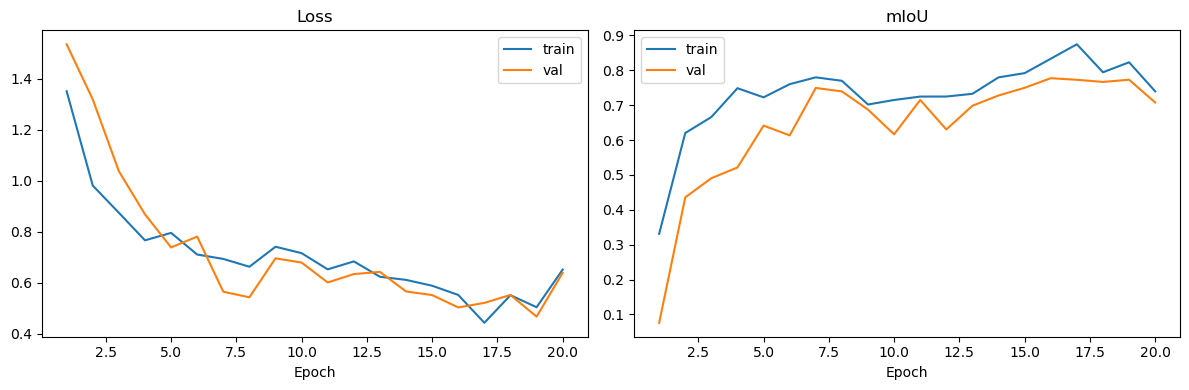

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_miou"], label="train")
axes[1].plot(history_df["epoch"], history_df["val_miou"], label="val")
axes[1].set_title("mIoU")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [43]:
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])

metrics, report = evaluate_model(model, test_df, band_mean, band_std)

print(f"mIoU: {metrics['IoU'].mean():.3f}")
display(metrics.sort_values("class_id"))
print()
print("Classification report")
print(report)


mIoU: 0.927


,class_id,class_name,IoU,support
0,1,Greenery,0.877587,106637
1,2,Sand,0.963942,178747
2,3,Water,0.928436,94187
3,4,Cement,0.937903,175213



Classification report
              precision    recall  f1-score   support

    Greenery       0.94      0.93      0.93    106637
        Sand       0.99      0.97      0.98    178748
       Water       0.93      1.00      0.96     94187
      Cement       0.97      0.96      0.97    175217

   micro avg       0.97      0.97      0.97    554789
   macro avg       0.96      0.97      0.96    554789
weighted avg       0.97      0.97      0.97    554789



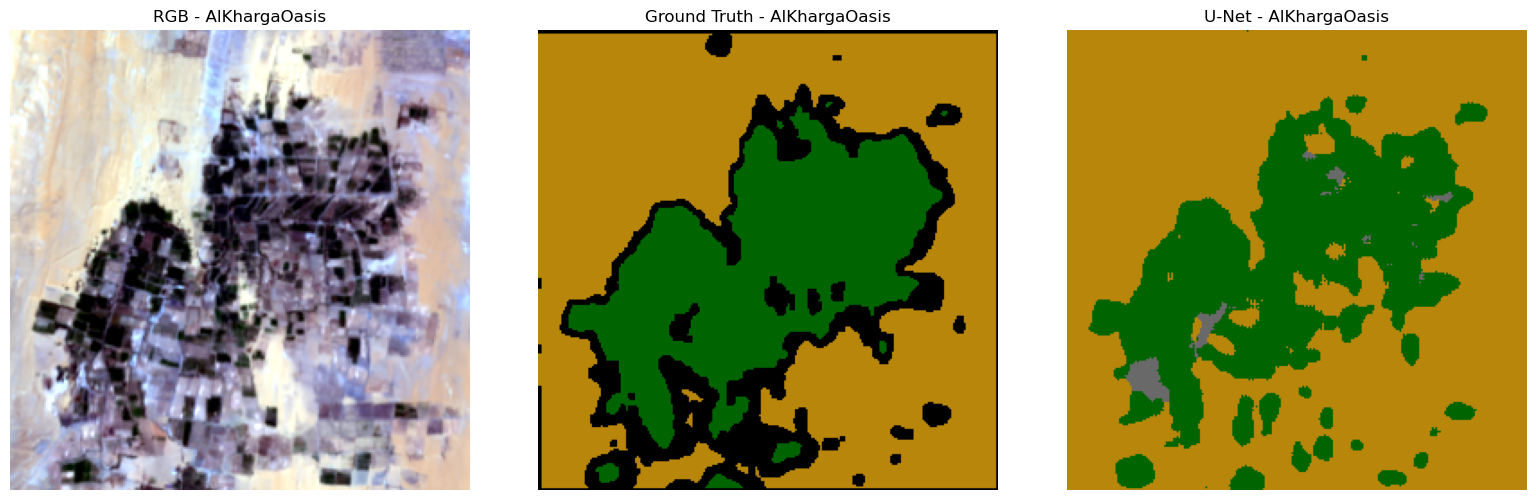

In [44]:
row = next(samples[samples["sample"].eq(TARGET_SAMPLE)].itertuples(index=False), None)
if row is None:
    raise ValueError(f"{TARGET_SAMPLE} not found in samples")

spectral, mask = load_sample(row)
pred, true, raw = predict_scene(model, spectral, mask, band_mean, band_std)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(rgb_preview(raw))
axes[0].set_title(f"RGB - {row.sample}")

axes[1].imshow(colorize(true))
axes[1].set_title(f"Ground Truth - {row.sample}")

axes[2].imshow(colorize(pred))
axes[2].set_title(f"U-Net - {row.sample}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [45]:
best_row = metrics.loc[metrics["IoU"].idxmax()]
worst_row = metrics.loc[metrics["IoU"].idxmin()]
best_epoch = history_df.loc[history_df["val_miou"].idxmax()]

print("Discussion")
print(
    f"U-Net used {len(train_df)} train scenes, {len(val_df)} val scenes and {len(test_df)} test scenes "
    f"for {EPOCHS} epochs at {IMAGE_SIZE}x{IMAGE_SIZE}."
)
print(
    f"Best val mIoU = {best_epoch['val_miou']:.3f} at epoch {int(best_epoch['epoch'])}, "
    f"and final test mIoU = {metrics['IoU'].mean():.3f}."
)
print(
    f"Best class: {best_row['class_name']} ({best_row['IoU']:.3f}). "
    f"Weakest class: {worst_row['class_name']} ({worst_row['IoU']:.3f})."
)
print(
    "This model captures spatial structure better, so large regions look cleaner, "
    "while class boundaries remain the main source of error."
)


Discussion
U-Net used 25 train scenes, 7 val scenes and 11 test scenes for 20 epochs at 256x256.
Best val mIoU = 0.777 at epoch 16, and final test mIoU = 0.927.
Best class: Sand (0.964). Weakest class: Greenery (0.878).
This model captures spatial structure better, so large regions look cleaner, while class boundaries remain the main source of error.
